# Was grandma right? Is it really the phone?

The full dataset was retrieved from [kaggle.com](https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health).


## Setup

Import libraries, load data, and customisation of columns.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json
import re
from pathlib import Path

# ── Data ─────────────────────────────────────────────────────────────────────
data = pd.read_csv('../data/smmh.csv')

# ── Gender normalisation ──────────────────────────────────────────────────────
data['Gender_Grouped'] = data['2. Gender'].replace({
    'Nonbinary ':          'Non-binary',
    'Non-binary':          'Non-binary',
    'NB':                  'Non-binary',
    'Non binary ':         'Non-binary',
    'Male':                'Male',
    'Female':              'Female',
    'unsure ':             'Other',
    'Trans':               'Other',
    'There are others???': 'Other',
})

# ── Column rename map ─────────────────────────────────────────────────────────
SHORT = {
    "1. What is your age?":                                                          "age",
    "Gender_Grouped":                                                                "gender",
    "3. Relationship Status":                                                        "relationship",
    "4. Occupation Status":                                                          "occupation",
    "5. What type of organizations are you affiliated with?":                        "org",
    "6. Do you use social media?":                                                   "uses_sm",
    "7. What social media platforms do you commonly use?":                           "platforms",
    "8. What is the average time you spend on social media every day?":              "daily_time",
    "9. How often do you find yourself using Social media without a specific purpose?":  "q9",
    "10. How often do you get distracted by Social media when you are busy doing something?": "q10",
    "11. Do you feel restless if you haven't used Social media in a while?":         "q11",
    "12. On a scale of 1 to 5, how easily distracted are you?":                     "q12",
    "13. On a scale of 1 to 5, how much are you bothered by worries?":              "q13",
    "14. Do you find it difficult to concentrate on things?":                        "q14",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "q15",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "q16",
    "17. How often do you look to seek validation from features of social media?":   "q17",
    "18. How often do you feel depressed or down?":                                  "q18",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "q19",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?":       "q20",
}

df = data.rename(columns={k: v for k, v in SHORT.items() if k in data.columns})

print(f"Dataset loaded: {len(df)} respondents, {df.shape[1]} columns")
df.head()


Dataset loaded: 481 respondents, 22 columns


,Timestamp,age,2. Gender,relationship,occupation,org,uses_sm,platforms,daily_time,q9,...,q12,q13,q14,q15,q16,q17,q18,q19,q20,gender
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,5,2,5,2,3,2,5,4,5,Male
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,4,5,4,5,1,1,5,4,5,Female
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,2,5,4,3,3,1,4,2,5,Female
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,3,5,3,5,1,2,4,3,2,Female
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,5,5,3,3,3,4,4,1,Female


## Introduction

To introduce our data to the user we present the cohort through simple pie charts: how many people actually use social media, which platforms are most popular, and how long users spend there daily. Pie charts work well here as they are easily readable and give the user a good first idea of the data.

Next, we also show bar charts with counts of the cohort's occupation, grouped marital status and gender, and summarise the mental-health questions before the user dives deeper into the analysis.

We present the basic statisctics in interactive manner. For further analysis we excluded the three non-users, as despite saying "no" when asked if they use social media, they replied to the rest of the questionaire.

In [2]:
# ── Top-level statistics ──────────────────────────────────────────────────────
out = {}

out["total"]    = int(len(df))
out["users"]    = int((df["uses_sm"] == "Yes").sum())  if "uses_sm" in df.columns else None
out["nonUsers"] = int((df["uses_sm"] == "No").sum())   if "uses_sm" in df.columns else None
out["avgAge"]   = round(float(df["age"].dropna().mean()), 1) if "age" in df.columns else None

# ── Users vs Non-users pie ────────────────────────────────────────────────────
if "uses_sm" in df.columns:
    vc = df["uses_sm"].value_counts()
    out["usersPie"] = [{"name": k, "value": int(v)} for k, v in vc.items()]

# ── Platforms pie ─────────────────────────────────────────────────────────────
PLATFORM_LIST = [
    "YouTube", "Instagram", "Facebook", "Twitter", "TikTok",
    "Snapchat", "Discord", "Pinterest", "Reddit", "LinkedIn",
]
if "platforms" in df.columns:
    counts_p = {}
    for p in PLATFORM_LIST:
        n = int(df["platforms"].dropna().str.contains(p, case=False, na=False).sum())
        if n:
            counts_p[p] = n
    out["platforms"] = sorted(
        [{"name": k, "value": v} for k, v in counts_p.items()],
        key=lambda x: -x["value"]
    )

# ── Age distribution ──────────────────────────────────────────────────────────
if "age" in df.columns:
    ages = df["age"].dropna()

    def age_label(a):
        if a < 15:  return "<15"
        if a <= 30: return str(int(a))
        if a <= 40: return "31-40"
        return "40+"

    age_series = ages.apply(age_label)
    order = [str(i) for i in range(15, 31)] + ["31-40", "40+", "<15"]
    vc = age_series.value_counts()
    out["ageBins"] = [
        {"label": lbl, "n": int(vc.get(lbl, 0))}
        for lbl in order if vc.get(lbl, 0) > 0
    ]

# ── Gender × Relationship ─────────────────────────────────────────────────────
if "gender" in df.columns and "relationship" in df.columns:
    preferred_rel = ["Single", "In a relationship", "Married", "Divorced"]
    cross = df.groupby(["relationship", "gender"]).size().unstack(fill_value=0)
    rel_order = [r for r in preferred_rel if r in cross.index] +                 [r for r in cross.index  if r not in preferred_rel]
    cross = cross.reindex(rel_order)

    out["relationship"] = []
    for rel in rel_order:
        row = {"status": rel, "total": int(cross.loc[rel].sum()), "breakdown": {}}
        for g in cross.columns:
            row["breakdown"][g] = int(cross.loc[rel, g])
        out["relationship"].append(row)

    out["genders"] = list(cross.columns)

# ── Occupation ────────────────────────────────────────────────────────────────
if "occupation" in df.columns:
    vc = df["occupation"].value_counts()
    out["occupation"] = [{"label": k, "n": int(v)} for k, v in vc.items()]

# ── Daily screen time ─────────────────────────────────────────────────────────
TIME_ORDER = [
    "Less than an Hour", "Between 1 and 2 hours", "Between 2 and 3 hours",
    "Between 3 and 4 hours", "Between 4 and 5 hours", "More than 5 hours",
]
if "daily_time" in df.columns:
    vc = df["daily_time"].value_counts()
    out["dailyTime"] = [
        {"label": lbl, "n": int(vc.get(lbl, 0))}
        for lbl in TIME_ORDER if vc.get(lbl, 0) > 0
    ]

# ── Mental-health question averages ──────────────────────────────────────────
MH_COLS = ["q9","q10","q11","q12","q13","q14","q15","q17","q18","q19","q20"]
mh_avgs = {}
for col in MH_COLS:
    if col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        mh_avgs[col] = round(float(numeric.mean()), 2) if numeric.notna().any() else None
out["mhAverages"] = mh_avgs

print(f"Total respondents : {out['total']}")
print(f"SM users          : {out['users']} ({out['users']/out['total']*100:.1f}%)")
print(f"Avg age           : {out['avgAge']}")


Total respondents : 481
SM users          : 478 (99.4%)
Avg age           : 26.1


Exporting .json

In [3]:
# ── Export survey_data.json ───────────────────────────────────────────────────
OUTPUT_PATH = "../html-files/survey_data.json"

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

print(f"✓ Exported {len(out)} sections → {OUTPUT_PATH}")


✓ Exported 12 sections → ../html-files/survey_data.json


## Each app and the associated stereotype

We wanted to find out whether the stereotypes are true. We grouped questions that have influence on particular stereotypes associated with specific apps and calculated mean scores per platform.


In [4]:
# ── Column definitions for stereotype analysis ────────────────────────────────
question_cols = {
    9:  "9. How often do you find yourself using Social media without a specific purpose?",
    10: "10. How often do you get distracted by Social media when you are busy doing something?",
    11: "11. Do you feel restless if you haven't used Social media in a while?",
    12: "12. On a scale of 1 to 5, how easily distracted are you?",
    13: "13. On a scale of 1 to 5, how much are you bothered by worries?",
    14: "14. Do you find it difficult to concentrate on things?",
    15: "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    16: "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    17: "17. How often do you look to seek validation from features of social media?",
    18: "18. How often do you feel depressed or down?",
    19: "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    20: "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

platform_col = "7. What social media platforms do you commonly use?"

platforms = [
    "Instagram", "Facebook", "Twitter", "YouTube", "Discord",
    "Pinterest", "TikTok", "Snapchat", "Reddit", "LinkedIn"
]

# ── Build per-platform score table ────────────────────────────────────────────
results = []
for platform in platforms:
    subset = data[data[platform_col].fillna("").str.contains(platform, case=False)]
    if len(subset) == 0:
        continue

    row = {
        "Platform":    platform,
        "Users":       len(subset),
        "Average Age": subset["1. What is your age?"].mean(),
    }
    for q_num, q_col in question_cols.items():
        row[f"Q{q_num}"] = pd.to_numeric(subset[q_col], errors="coerce").mean()

    results.append(row)

platform_scores = pd.DataFrame(results)
print(platform_scores.round(2))


    Platform  Users  Average Age    Q9   Q10   Q11   Q12   Q13   Q14   Q15  \
0  Instagram    359        24.37  3.64  3.48  2.67  3.48  3.75  3.39  2.93   
1   Facebook    407        26.15  3.58  3.40  2.64  3.36  3.61  3.28  2.92   
2    Twitter    131        26.89  3.54  3.18  2.55  3.34  3.68  3.16  2.66   
3    YouTube    412        25.87  3.59  3.34  2.59  3.35  3.60  3.24  2.85   
4    Discord    198        22.81  3.67  3.43  2.55  3.48  3.75  3.40  2.79   
5  Pinterest    145        24.57  3.62  3.36  2.57  3.35  3.72  3.17  2.85   
6     TikTok     94        23.67  3.84  3.78  3.02  3.80  4.03  3.66  3.40   
7   Snapchat    181        22.76  3.72  3.60  2.78  3.61  3.84  3.51  3.04   
8     Reddit    126        23.56  3.68  3.20  2.38  3.43  3.73  3.30  2.60   

    Q16   Q17   Q18   Q19   Q20  
0  2.75  2.54  3.40  3.28  3.30  
1  2.74  2.53  3.31  3.17  3.25  
2  2.75  2.31  3.25  2.97  3.21  
3  2.78  2.46  3.28  3.18  3.22  
4  2.85  2.38  3.41  3.18  3.40  
5  2.79  2.50  

The heatmap below lets us see scores for each question and platform at a glance. Two patters stand out:

- **Q9** (How often do you find yourself using Social media without a specific purpose?) and **Q13** (On a scale of 1 to 5, how much are you bothered by worries?) have the highest scores across all platforms
- **TikTok** shows generally elevated scores despite having one of the smaller user counts in this cohort.

For the website we represent this data as a word map where the larger the platform name, the higher it scored on a given question.


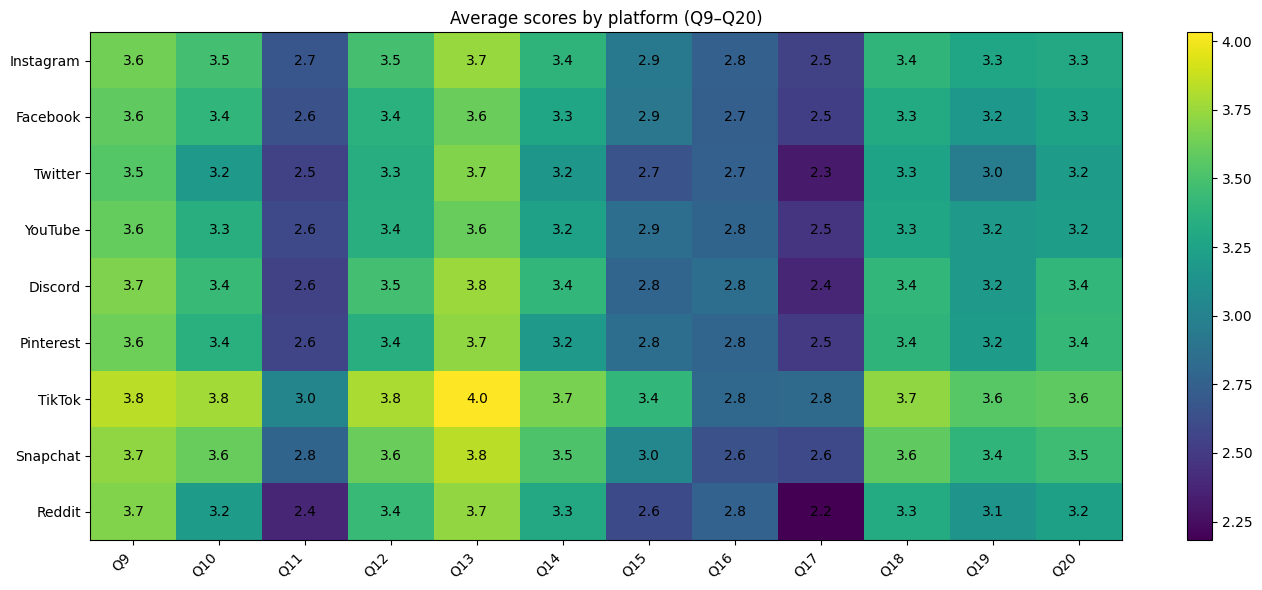

In [5]:
# ── Heatmap: average scores by platform ──────────────────────────────────────
score_cols = [f"Q{i}" for i in range(9, 21)]
heatmap_data = platform_scores.set_index("Platform")[score_cols]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_data, aspect='auto')

ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(score_cols)
ax.set_yticklabels(heatmap_data.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(heatmap_data.index)):
    for j in range(len(score_cols)):
        ax.text(j, i, f"{heatmap_data.iloc[i, j]:.1f}", ha="center", va="center")

ax.set_title("Average scores by platform (Q9–Q20)")
fig.colorbar(im)
plt.tight_layout()
plt.show()


After seeing the heatmap, we suspect TikTok is associated with many negative mental-health effects. We choose to make a separate analysis of the TikTok users, but for further analysis in this section, we exclude it to reveal clearer patterns among the other apps.


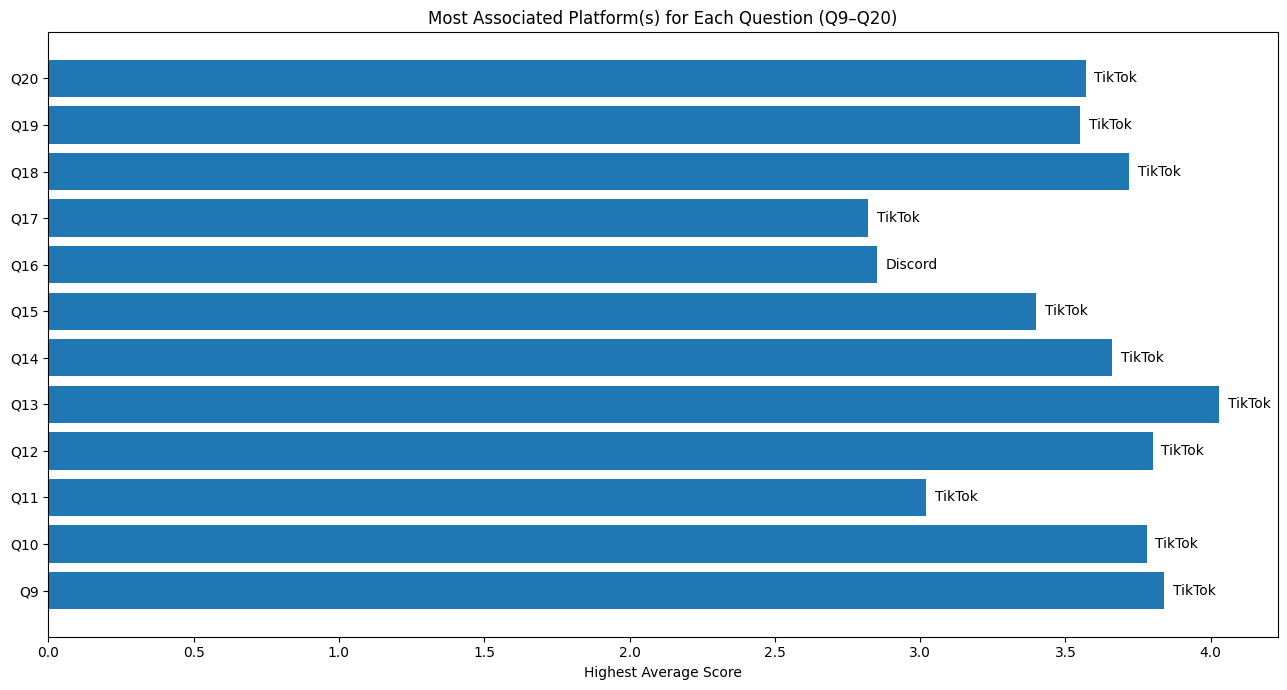

Question Most Associated Platform(s)  Average Score
      Q9                      TikTok           3.84
     Q10                      TikTok           3.78
     Q11                      TikTok           3.02
     Q12                      TikTok           3.80
     Q13                      TikTok           4.03
     Q14                      TikTok           3.66
     Q15                      TikTok           3.40
     Q16                     Discord           2.85
     Q17                      TikTok           2.82
     Q18                      TikTok           3.72
     Q19                      TikTok           3.55
     Q20                      TikTok           3.57


In [6]:
# ── Most associated platform per question (including ties) ────────────────────
summary_rows = []
for q_num in range(9, 21):
    q_col = f"Q{q_num}"
    max_score = platform_scores[q_col].max()
    best = platform_scores.loc[platform_scores[q_col] == max_score, "Platform"].tolist()
    summary_rows.append({
        "Question": q_col,
        "Most Associated Platform(s)": ", ".join(best),
        "Average Score": round(max_score, 2)
    })

summary_data = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(summary_data["Question"], summary_data["Average Score"])

for i, bar in enumerate(bars):
    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        summary_data.iloc[i]["Most Associated Platform(s)"],
        va="center"
    )

ax.set_xlabel("Highest Average Score")
ax.set_title("Most Associated Platform(s) for Each Question (Q9–Q20)")
plt.tight_layout()
plt.show()

print(summary_data.to_string(index=False))


## People & platform profiles

This section dives into specific subgroups:

- **TikTok users** — demographics and co-used apps
- **Light scrollers** — respondents spending less than one hour online daily
- **60+ users** — which apps are popular and how long they spend online
- **Outliers** — respondents with maximum mental-health scores, plus the youngest and oldest respondents
- **Non-users** — a small-n descriptive look at the three respondents who said they don't use social media


In [7]:
# ── Shared helpers ────────────────────────────────────────────────────────────
age_col         = "1. What is your age?"
gender_col      = "2. Gender"
relationship_col = "3. Relationship Status"
occupation_col  = "4. Occupation Status"
affiliation_col = "5. What type of organizations are you affiliated with?"
use_col         = "6. Do you use social media?"
platform_col    = "7. What social media platforms do you commonly use?"
time_col        = "8. What is the average time you spend on social media every day?"

question_cols_str = {
    "Q9":  "9. How often do you find yourself using Social media without a specific purpose?",
    "Q10": "10. How often do you get distracted by Social media when you are busy doing something?",
    "Q11": "11. Do you feel restless if you haven't used Social media in a while?",
    "Q12": "12. On a scale of 1 to 5, how easily distracted are you?",
    "Q13": "13. On a scale of 1 to 5, how much are you bothered by worries?",
    "Q14": "14. Do you find it difficult to concentrate on things?",
    "Q15": "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    "Q16": "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    "Q17": "17. How often do you look to seek validation from features of social media?",
    "Q18": "18. How often do you feel depressed or down?",
    "Q19": "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    "Q20": "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

# Coerce numeric columns in `data`
data[age_col] = pd.to_numeric(data[age_col], errors="coerce")
for _, col in question_cols_str.items():
    data[col] = pd.to_numeric(data[col], errors="coerce")

def has_platform(series, platform):
    return series.fillna("").str.contains(platform, case=False, regex=False)

def value_counts_payload(series, top_n=None):
    vc = series.fillna("Unknown").value_counts()
    if top_n:
        vc = vc.head(top_n)
    total = int(vc.sum()) or 1
    return [{"label": str(k), "n": int(v), "pct": round(v / total * 100, 1)} for k, v in vc.items()]

def multi_platform_counts(subset):
    rows = []
    for p in platforms:
        n = int(has_platform(subset[platform_col], p).sum())
        if n > 0:
            rows.append({"platform": p, "n": n, "pct": round(n / max(len(subset), 1) * 100, 1)})
    return sorted(rows, key=lambda x: x["n"], reverse=True)

def time_sort_key(label):
    order = {
        "Less than an Hour": 0, "Less than an hour": 0,
        "Between 1 and 2 hours": 1, "Between 2 and 3 hours": 2,
        "Between 3 and 4 hours": 3, "Between 4 and 5 hours": 4,
        "More than 5 hours": 5,
    }
    return order.get(str(label), 99)


### TikTok users

TikTok users in this cohort are typically single university students. Instagram is their most common second platform.


In [8]:
# ── TikTok subgroup ───────────────────────────────────────────────────────────
tiktok_users = data[has_platform(data[platform_col], "TikTok")].copy()

tiktok_other_apps = sorted([
    {
        "label": app, "platform": app,
        "n": int(has_platform(tiktok_users[platform_col], app).sum()),
        "pct": round(has_platform(tiktok_users[platform_col], app).sum() / max(len(tiktok_users), 1) * 100, 1)
    }
    for app in platforms if app != "TikTok"
], key=lambda x: x["n"], reverse=True)

tiktok_payload = {
    "n":            int(len(tiktok_users)),
    "ageMean":      round(tiktok_users[age_col].mean(), 1) if len(tiktok_users) else None,
    "occupation":   value_counts_payload(tiktok_users[occupation_col]),
    "relationship": value_counts_payload(tiktok_users[relationship_col]),
    "otherApps":    tiktok_other_apps,
}

print(f"TikTok users: {tiktok_payload['n']}  |  Avg age: {tiktok_payload['ageMean']}")
print("Top co-used apps:", [a["label"] for a in tiktok_other_apps[:5]])


TikTok users: 94  |  Avg age: 23.7
Top co-used apps: ['Instagram', 'YouTube', 'Facebook', 'Snapchat', 'Discord']


### Light scrollers

People spending less than an hour online daily tend to be male, 45–59 years old, and salaried workers. Facebook dominates this subgroup; TikTok has only two users here.


In [9]:
# ── Light users (< 1 h/day) ───────────────────────────────────────────────────
light_users = data[data[time_col].fillna("").str.contains("Less than", case=False, regex=False)].copy()

age_bins   = [0, 17, 24, 34, 44, 59, 200]
age_labels = ["≤17", "18–24", "25–34", "35–44", "45–59", "60+"]

light_users["age_bin"] = pd.cut(
    light_users[age_col], bins=age_bins, labels=age_labels, include_lowest=True
)

light_age_dist = light_users["age_bin"].value_counts().reindex(age_labels, fill_value=0)

light_age_payload        = [{"ageGroup": str(k), "n": int(v)} for k, v in light_age_dist.items()]
light_gender_payload     = value_counts_payload(light_users[gender_col])
light_occupation_payload = value_counts_payload(light_users[occupation_col])
light_app_payload        = multi_platform_counts(light_users)

print(f"Light users: {len(light_users)}")
print("Top apps:", [a["platform"] for a in light_app_payload[:5]])


Light users: 34
Top apps: ['Facebook', 'YouTube', 'Instagram', 'Twitter', 'Discord']


### 60+ respondents

We have only 4 respondents aged 60 or above. The most popular apps are Facebook and YouTube. All spend more than one hour online daily.


In [10]:
# ── 60+ users ─────────────────────────────────────────────────────────────────
older = data[data[age_col] >= 60].copy()

older_time = (
    older[time_col]
    .fillna("Unknown")
    .value_counts()
    .sort_index(key=lambda idx: [time_sort_key(x) for x in idx])
)

older_payload = {
    "n":       int(len(older)),
    "ageMean": round(older[age_col].mean(), 1) if len(older) else None,
    "ageMin":  int(older[age_col].min()) if len(older) else None,
    "ageMax":  int(older[age_col].max()) if len(older) else None,
    "apps":    multi_platform_counts(older),
    "time":    [
        {"label": str(k), "n": int(v), "pct": round(v / max(len(older), 1) * 100, 1)}
        for k, v in older_time.items()
    ],
}

print(f"60+ respondents: {older_payload['n']}  |  Age range: {older_payload['ageMin']}–{older_payload['ageMax']}")
print("Apps:", [a["platform"] for a in older_payload["apps"]])


60+ respondents: 4  |  Age range: 60–91
Apps: ['Facebook', 'YouTube', 'Instagram', 'Discord', 'TikTok', 'Snapchat']


### Outliers

We identify respondents with a perfect 5/5 average across questions 9–20, plus the youngest and oldest respondent. Cards are shown for each so that the user can interpret the data themselves without drawing broad conclusions from a tiny sample.


In [11]:
# ── Outliers / extremes ───────────────────────────────────────────────────────
score_cols_list = list(question_cols_str.values())

data["mean_mh_score"] = data[score_cols_list].mean(axis=1)
data["n_5_scores"]    = (data[score_cols_list] == 5).sum(axis=1)

perfect = data[data["mean_mh_score"] == 5].copy()

perfect_rows = [
    {
        "row":          int(idx),
        "age":          None if pd.isna(r[age_col]) else float(r[age_col]),
        "gender":       str(r.get(gender_col, "Unknown")),
        "occupation":   str(r.get(occupation_col, "Unknown")),
        "relationship": str(r.get(relationship_col, "Unknown")),
        "platforms":    str(r.get(platform_col, "")),
        "time":         str(r.get(time_col, "")),
        "meanScore":    round(float(r["mean_mh_score"]), 2),
        "nFive":        int(r["n_5_scores"]),
    }
    for idx, r in perfect.iterrows()
]

age_valid = data[data[age_col].notna()].copy()
youngest  = age_valid.loc[age_valid[age_col].idxmin()]
oldest    = age_valid.loc[age_valid[age_col].idxmax()]

def person_payload(row):
    return {
        "row":          int(row.name),
        "age":          float(row[age_col]),
        "gender":       str(row.get(gender_col, "Unknown")),
        "occupation":   str(row.get(occupation_col, "Unknown")),
        "relationship": str(row.get(relationship_col, "Unknown")),
        "affiliation":  str(row.get(affiliation_col, "Unknown")),
        "usesSocial":   str(row.get(use_col, "Unknown")),
        "platforms":    str(row.get(platform_col, "")),
        "time":         str(row.get(time_col, "")),
        "meanScore":    round(float(row[score_cols_list].mean()), 2) if row[score_cols_list].notna().any() else None,
    }

outlier_payload = {
    "perfectScorePeople": perfect_rows,
    "perfectCount":       int(len(perfect_rows)),
    "youngest":           person_payload(youngest),
    "oldest":             person_payload(oldest),
}

print(f"Respondents with 5/5 average: {outlier_payload['perfectCount']}")
print(f"Youngest: {outlier_payload['youngest']['age']} yrs  |  Oldest: {outlier_payload['oldest']['age']} yrs")


Respondents with 5/5 average: 5
Youngest: 13.0 yrs  |  Oldest: 91.0 yrs


### Non-users

Three respondents said they do not use social media but still answered the mental-health questions. We keep them as a clearly labelled separate group to avoid misleading comparisons.


In [12]:
# ── Non-users ─────────────────────────────────────────────────────────────────
non_users = data[data[use_col] == "No"].copy()

print("All data for non-users:")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(non_users.to_string())


All data for non-users:
              Timestamp  1. What is your age? 2. Gender 3. Relationship Status 4. Occupation Status 5. What type of organizations are you affiliated with? 6. Do you use social media? 7. What social media platforms do you commonly use? 8. What is the average time you spend on social media every day?  9. How often do you find yourself using Social media without a specific purpose?  10. How often do you get distracted by Social media when you are busy doing something?  11. Do you feel restless if you haven't used Social media in a while?  12. On a scale of 1 to 5, how easily distracted are you?  13. On a scale of 1 to 5, how much are you bothered by worries?  14. Do you find it difficult to concentrate on things?  15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?  16. Following the previous question, how do you feel about these comparisons, generally speaking?  17. How often do you look to seek vali

In [13]:
# Non-user payload for the HTML output
question_labels_map = {
    "Q9":  "Purposeless use",       "Q10": "Distracted while busy",
    "Q11": "Restless offline",      "Q12": "Easily distracted",
    "Q13": "Bothered by worries",   "Q14": "Concentration issues",
    "Q15": "Social comparison",     "Q16": "Feeling after comparison",
    "Q17": "Validation seeking",    "Q18": "Feeling down",
    "Q19": "Interest fluctuation",  "Q20": "Sleep issues",
}

non_user_scores = []
for q_key, q_col in question_cols_str.items():
    scores = pd.to_numeric(non_users[q_col], errors="coerce")
    non_user_scores.append({
        "question": q_key,
        "full":     q_col,
        "label":    question_labels_map.get(q_key, q_key),
        "score":    round(float(scores.mean()), 2) if scores.notna().any() else None,
    })

non_user_payload = {
    "n":      int(len(non_users)),
    "scores": non_user_scores,
    "people": [
        {
            "row":          int(idx),
            "age":          None if pd.isna(r[age_col]) else float(r[age_col]),
            "gender":       str(r.get(gender_col, "Unknown")),
            "occupation":   str(r.get(occupation_col, "Unknown")),
            "relationship": str(r.get(relationship_col, "Unknown")),
            "meanScore":    round(float(r[list(question_cols_str.values())].mean()), 2)
                            if r[list(question_cols_str.values())].notna().any() else None,
        }
        for idx, r in non_users.iterrows()
    ],
}

print(f"Non-users: {non_user_payload['n']}")


Non-users: 3


In [ ]:
# ── Assemble final payload and write others.html ──────────────────────────────
out_html = "../html-files/others.html"
Path(out_html).parent.mkdir(parents=True, exist_ok=True)


# ── Final payload ────────────────────────────────────────────────────────────
payload = {
    "tiktok": tiktok_payload,
    "lightUsers": {
        "n": int(len(light_users)),
        "ageDistribution": light_age_payload,
        "genderDistribution": light_gender_payload,
        "occupationDistribution": light_occupation_payload,
        "apps": light_app_payload
    },
    "older60": older_payload,
    "outliers": outlier_payload,
    "nonUsers": non_user_payload
}

DATA_JSON = json.dumps(payload, indent=2)

# ── Full HTML template ───────────────────────────────────────────────────────
html = r'''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Who Are Extremes?</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;0,900;1,400;1,700&family=DM+Mono:wght@300;400;500&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>

<style>
:root {
  --cream:#F5F0E8;
  --dark:#1A1209;
  --warm:#C8A96E;
  --accent:#E8472A;
  --muted:#6B5E4A;
  --card:#FFFDF7;
  --border:rgba(200,169,110,0.28);
}

* {
  box-sizing:border-box;
  margin:0;
  padding:0;
}

body {
  background:var(--cream);
  color:var(--dark);
  font-family:'DM Sans',sans-serif;
  font-weight:300;
  line-height:1.7;
  overflow-x:hidden;
}

.hero {
  min-height:72vh;
  display:flex;
  flex-direction:column;
  justify-content:center;
  align-items:center;
  text-align:center;
  padding:4rem 2rem;
  position:relative;
  overflow:hidden;
}

.hero::before {
  content:'';
  position:absolute;
  inset:0;
  background:
    repeating-linear-gradient(0deg,transparent,transparent 39px,rgba(200,169,110,.11) 39px,rgba(200,169,110,.11) 40px),
    repeating-linear-gradient(90deg,transparent,transparent 39px,rgba(200,169,110,.11) 39px,rgba(200,169,110,.11) 40px);
  pointer-events:none;
}

.eyebrow {
  font-family:'DM Mono',monospace;
  font-size:11px;
  letter-spacing:.22em;
  text-transform:uppercase;
  color:var(--muted);
  margin-bottom:2rem;
  position:relative;
}

.hero h1 {
  font-family:'Playfair Display',serif;
  font-size:clamp(3rem,8vw,6.5rem);
  font-weight:900;
  line-height:1;
  max-width:950px;
  position:relative;
}

.hero h1 em {
  color:var(--accent);
  font-style:italic;
}

.hero-sub {
  max-width:620px;
  color:var(--muted);
  margin-top:1.75rem;
  position:relative;
}

section {
  max-width:1100px;
  margin:0 auto;
  padding:5rem 2rem;
}

.sec-label {
  font-family:'DM Mono',monospace;
  font-size:10px;
  letter-spacing:.25em;
  text-transform:uppercase;
  color:var(--warm);
  margin-bottom:.9rem;
}

h2 {
  font-family:'Playfair Display',serif;
  font-size:clamp(2rem,4vw,3rem);
  line-height:1.15;
  margin-bottom:.9rem;
}

.lead {
  max-width:720px;
  color:var(--muted);
  margin-bottom:2rem;
}

.card {
  background:var(--card);
  border:1px solid var(--border);
  border-radius:18px;
  padding:2rem;
  margin-bottom:1.5rem;
  box-shadow:0 10px 30px rgba(26,18,9,.04);
}

.dark-card {
  background:var(--dark);
  color:var(--cream);
  border-radius:24px;
  padding:2.4rem;
  border:1px solid rgba(200,169,110,.25);
  box-shadow:0 18px 45px rgba(26,18,9,.18);
  margin-bottom:1.5rem;
}

.grid-2 {
  display:grid;
  grid-template-columns:1fr 1fr;
  gap:1.5rem;
}

.grid-3 {
  display:grid;
  grid-template-columns:repeat(3,1fr);
  gap:1rem;
}

.chart-wrap {
  position:relative;
  height:330px;
}

.chart-small {
  height:270px;
}

.stat {
  background:rgba(245,240,232,.06);
  border:1px solid rgba(200,169,110,.18);
  border-radius:16px;
  padding:1.2rem;
}

.stat-num {
  font-family:'Playfair Display',serif;
  font-size:2.4rem;
  font-weight:900;
  color:var(--warm);
  display:block;
  line-height:1;
}

.stat-label {
  font-family:'DM Mono',monospace;
  font-size:9px;
  letter-spacing:.15em;
  text-transform:uppercase;
  color:rgba(245,240,232,.55);
  margin-top:.5rem;
}

.table {
  width:100%;
  border-collapse:collapse;
  font-family:'DM Mono',monospace;
  font-size:11px;
}

.table th,
.table td {
  border-bottom:1px solid var(--border);
  padding:.75rem .45rem;
  text-align:left;
}

.table th {
  color:var(--muted);
  text-transform:uppercase;
  font-size:9px;
  letter-spacing:.12em;
}

.person-card {
  background:var(--dark);
  color:var(--cream);
  border-radius:20px;
  padding:1.6rem;
  border:1px solid rgba(200,169,110,.25);
  position:relative;
  overflow:hidden;
}

.person-card::after {
  content:attr(data-age);
  position:absolute;
  right:1rem;
  top:-.6rem;
  font-family:'Playfair Display',serif;
  font-weight:900;
  font-size:5rem;
  color:rgba(200,169,110,.11);
  line-height:1;
}

.person-title {
  font-family:'Playfair Display',serif;
  font-size:1.6rem;
  font-weight:900;
  margin-bottom:.35rem;
}

.person-meta {
  color:rgba(245,240,232,.7);
  font-size:.9rem;
  max-width:85%;
}

.person-detail {
  font-family:'DM Mono',monospace;
  font-size:10px;
  color:rgba(245,240,232,.55);
  margin-top:1rem;
  line-height:1.7;
}

.severity-grid {
  display:grid;
  grid-template-columns:repeat(auto-fit,minmax(230px,1fr));
  gap:14px;
}

.severity-card {
  background:linear-gradient(135deg,rgba(232,71,42,.18),rgba(200,169,110,.10));
  border:1px solid rgba(232,71,42,.25);
  border-radius:18px;
  padding:1.4rem;
  min-height:180px;
}

.severity-title {
  font-family:'Playfair Display',serif;
  font-size:1.4rem;
  font-weight:900;
}

.severity-score {
  font-family:'Playfair Display',serif;
  font-size:2.4rem;
  font-weight:900;
  color:var(--accent);
  line-height:1;
  margin:.8rem 0;
}

.severity-meta {
  font-family:'DM Mono',monospace;
  font-size:10px;
  color:var(--muted);
  line-height:1.7;
}

.note {
  font-size:.9rem;
  color:var(--muted);
  background:rgba(200,169,110,.12);
  border-left:3px solid var(--warm);
  padding:1rem;
  border-radius:10px;
  margin-bottom:1.5rem;
}

.toggle-row {
  display:flex;
  flex-wrap:wrap;
  gap:.5rem;
  margin-bottom:1rem;
}

.toggle-btn {
  border:1px solid var(--border);
  background:rgba(255,253,247,.8);
  color:var(--dark);
  border-radius:999px;
  padding:.45rem .75rem;
  font-family:'DM Mono',monospace;
  font-size:10px;
  letter-spacing:.1em;
  text-transform:uppercase;
  cursor:pointer;
}

.toggle-btn.active {
  background:var(--dark);
  color:var(--cream);
}

@media(max-width:780px) {
  .grid-2,
  .grid-3 {
    grid-template-columns:1fr;
  }

  .chart-wrap {
    height:300px;
  }
}
</style>
</head>

<body>

<div class="hero">
  <p class="eyebrow">A closer look at the respondents</p>
  <h1>Let’s look at the <em>extremes</em></h1>
  <p class="hero-sub">
    Want to know what else the TikTokers are doing? Where are the light scrollers?
    How are the non-users doing mentally? And what are the other outliers?
    This page shows the profiles of these different subgroups.
  </p>
</div>

<section id="tiktok">
  <p class="sec-label">02 — TikTok users</p>
  <h2>Who are the TikTok users?</h2>
  <p class="lead">
    This section only counts respondents who reported using TikTok. The plots show their occupation,
    relationship status, and which other apps are popular among them.
  </p>

  <div class="dark-card">
    <div class="grid-3" id="tiktokStats"></div>
  </div>

  <div class="grid-2">
    <div class="card">
      <h3>Occupation among TikTok users</h3>
      <div class="chart-wrap chart-small">
        <canvas id="tiktokOccupationPie"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Relationship status among TikTok users</h3>
      <div class="chart-wrap chart-small">
        <canvas id="tiktokRelationshipPie"></canvas>
      </div>
    </div>
  </div>

  <div class="card">
    <h3>What other apps are popular among TikTok users?</h3>
    <p class="note">
      Respondents could select multiple platforms. These values show how many TikTok users also use each app.
    </p>
    <div class="chart-wrap">
      <canvas id="tiktokOtherAppsChart"></canvas>
    </div>
  </div>
</section>

<section id="light">
  <p class="sec-label">03 — Light users</p>
  <h2>Who spends less than one hour online?</h2>
  <p class="lead">
    This section focuses only on people reporting less than one hour of social media per day.
  </p>

  <div class="grid-2">
    <div class="card">
      <h3>Who are the light users?</h3>
      <p class="note">
        Choose whether to view light users by age, gender, or occupation.
      </p>

      <div class="toggle-row">
        <button class="toggle-btn active" onclick="updateLightProfileChart('age', this)">Age</button>
        <button class="toggle-btn" onclick="updateLightProfileChart('gender', this)">Gender</button>
        <button class="toggle-btn" onclick="updateLightProfileChart('occupation', this)">Occupation</button>
      </div>

      <div class="chart-wrap">
        <canvas id="lightProfileChart"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Apps used by light users</h3>
      <div class="chart-wrap">
        <canvas id="lightAppsChart"></canvas>
      </div>
    </div>
  </div>
</section>

<section id="older">
  <p class="sec-label">04 — Older respondents</p>
  <h2>What about people aged 60+?</h2>
  <p class="lead">
    For older respondents, the page reports the most used apps and how much time they spend on social media.
  </p>

  <div class="dark-card">
    <div class="grid-3" id="olderStats"></div>
  </div>

  <div class="grid-2">
    <div class="card">
      <h3>Most used apps among 60+</h3>
      <div class="chart-wrap">
        <canvas id="olderAppsChart"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Daily time among 60+</h3>
      <div class="chart-wrap">
        <canvas id="olderTimeChart"></canvas>
      </div>
    </div>
  </div>
</section>

<section id="outliers">
  <p class="sec-label">05 — Outliers and extremes</p>
  <h2>The most extreme profiles.</h2>
  <p class="lead">
    This section shows respondents with a perfect 5/5 average across all mental-health questions,
    plus the youngest and oldest respondent profiles.
  </p>

  <div class="card">
    <h3>Most severe health scores</h3>
    <p class="note">
      Only respondents with an average score of exactly 5/5 across questions 9–20 are shown here.
    </p>
    <div class="severity-grid" id="severityCards"></div>
  </div>

  <div class="grid-2" id="ageExtremeCards"></div>
</section>

<section id="nonusers">
  <p class="sec-label">06 — Non-users</p>
  <h2>The last free souls or outLiars?</h2>
  <p class="lead">
    Three respondents reported not using social media at all. However, they still replied to the mental-health questions, 
    thus we treat them as a separate group.
  </p>

  <div class="card">
    <h3>Non-user respondent table</h3>
    <table class="table" id="nonUserTable"></table>
  </div>

  <div class="card">
    <h3>Non-user scores across mental-health questions</h3>
    <div class="chart-wrap">
      <canvas id="nonUserChart"></canvas>
    </div>
  </div>

  <div class="dark-card">
    <p id="nonUserIntro"></p>
  </div>
</section>

<script>
const D = __DATA_JSON__;

const COLORS = [
  "#E8472A", "#C8A96E", "#534AB7", "#185FA5", "#D4537E",
  "#3B6D11", "#BA7517", "#888780", "#0F6E56", "#A64253"
];

Chart.defaults.font.family = "'DM Mono', monospace";
Chart.defaults.color = "#6B5E4A";

function makePie(id, rows) {
  const el = document.getElementById(id);
  if (!el) return;

  new Chart(el, {
    type: "doughnut",
    data: {
      labels: rows.map(x => x.label),
      datasets: [{
        data: rows.map(x => x.n),
        backgroundColor: COLORS,
        borderColor: "#FFFDF7",
        borderWidth: 3
      }]
    },
    options: {
      responsive: true,
      maintainAspectRatio: false,
      cutout: "58%",
      plugins: {
        legend: {
          position: "bottom",
          labels: {
            boxWidth: 10,
            font: { size: 10 }
          }
        },
        tooltip: {
          callbacks: {
            label: c => ` ${c.label}: ${c.parsed} (${rows[c.dataIndex].pct}%)`
          }
        }
      }
    }
  });
}

/* -----------------------------
   SECTION 02: TIKTOK USERS
----------------------------- */
document.getElementById("tiktokStats").innerHTML = `
  <div class="stat">
    <span class="stat-num">${D.tiktok.n}</span>
    <div class="stat-label">TikTok users</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.tiktok.ageMean ?? "—"}</span>
    <div class="stat-label">Average age</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.tiktok.otherApps[0]?.label ?? "—"}</span>
    <div class="stat-label">Most common other app</div>
  </div>
`;

makePie("tiktokOccupationPie", D.tiktok.occupation);
makePie("tiktokRelationshipPie", D.tiktok.relationship);

new Chart(document.getElementById("tiktokOtherAppsChart"), {
  type: "bar",
  data: {
    labels: D.tiktok.otherApps.map(x => x.label),
    datasets: [{
      data: D.tiktok.otherApps.map(x => x.n),
      backgroundColor: "#E8472Abb",
      borderColor: "#E8472A",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} TikTok users (${D.tiktok.otherApps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: {
          display: true,
          text: "Number of TikTok users also using this app"
        }
      },
      y: { grid: { display: false } }
    }
  }
});

/* -----------------------------
   SECTION 03: LIGHT USERS
----------------------------- */
let lightProfileChart = null;

function updateLightProfileChart(mode, btn = null) {
  if (btn) {
    document.querySelectorAll(".toggle-btn").forEach(b => b.classList.remove("active"));
    btn.classList.add("active");
  }

  let labels;
  let values;
  let xTitle;

  if (mode === "age") {
    labels = D.lightUsers.ageDistribution.map(x => x.ageGroup);
    values = D.lightUsers.ageDistribution.map(x => x.n);
    xTitle = "Age group";
  } else if (mode === "gender") {
    labels = D.lightUsers.genderDistribution.map(x => x.label);
    values = D.lightUsers.genderDistribution.map(x => x.n);
    xTitle = "Gender";
  } else {
    labels = D.lightUsers.occupationDistribution.map(x => x.label);
    values = D.lightUsers.occupationDistribution.map(x => x.n);
    xTitle = "Occupation";
  }

  if (lightProfileChart) {
    lightProfileChart.destroy();
  }

  lightProfileChart = new Chart(document.getElementById("lightProfileChart"), {
    type: "bar",
    data: {
      labels: labels,
      datasets: [{
        data: values,
        backgroundColor: "#E8472Abb",
        borderColor: "#E8472A",
        borderWidth: 1
      }]
    },
    options: {
      responsive: true,
      maintainAspectRatio: false,
      plugins: { legend: { display: false } },
      scales: {
        x: {
          grid: { display: false },
          ticks: {
            maxRotation: 35,
            minRotation: 20
          },
          title: { display: true, text: xTitle }
        },
        y: {
          beginAtZero: true,
          ticks: { stepSize: 1, precision: 0 },
          title: { display: true, text: "Number of light users" },
          grid: { color: "rgba(200,169,110,.15)" }
        }
      }
    }
  });
}

updateLightProfileChart("age");

new Chart(document.getElementById("lightAppsChart"), {
  type: "bar",
  data: {
    labels: D.lightUsers.apps.map(x => x.platform),
    datasets: [{
      data: D.lightUsers.apps.map(x => x.n),
      backgroundColor: "#C8A96Ebb",
      borderColor: "#C8A96E",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} users (${D.lightUsers.apps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of light users" }
      },
      y: { grid: { display: false } }
    }
  }
});

/* -----------------------------
   SECTION 04: 60+ USERS
----------------------------- */
document.getElementById("olderStats").innerHTML = `
  <div class="stat">
    <span class="stat-num">${D.older60.n}</span>
    <div class="stat-label">Respondents aged 60+</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.older60.ageMean ?? "—"}</span>
    <div class="stat-label">Average age</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.older60.ageMin ?? "—"}–${D.older60.ageMax ?? "—"}</span>
    <div class="stat-label">Age range</div>
  </div>
`;

new Chart(document.getElementById("olderAppsChart"), {
  type: "bar",
  data: {
    labels: D.older60.apps.map(x => x.platform),
    datasets: [{
      data: D.older60.apps.map(x => x.n),
      backgroundColor: "#534AB7bb",
      borderColor: "#534AB7",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} users (${D.older60.apps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of 60+ users" }
      },
      y: { grid: { display: false } }
    }
  }
});

new Chart(document.getElementById("olderTimeChart"), {
  type: "bar",
  data: {
    labels: D.older60.time.map(x => x.label),
    datasets: [{
      data: D.older60.time.map(x => x.n),
      backgroundColor: "#3B6D11bb",
      borderColor: "#3B6D11",
      borderWidth: 1
    }]
  },
  options: {
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.y} respondents (${D.older60.time[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        grid: { display: false },
        ticks: { maxRotation: 35, minRotation: 25 }
      },
      y: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of 60+ respondents" }
      }
    }
  }
});

/* -----------------------------
   SECTION 05: OUTLIERS
----------------------------- */
const severity = D.outliers.perfectScorePeople;

document.getElementById("severityCards").innerHTML = severity.length
  ? severity.map(p => `
    <div class="severity-card">
      <div class="severity-title">Respondent ${p.row}</div>
      <div class="severity-score">5.00 / 5</div>
      <div class="severity-meta">
        Age: ${p.age ?? "Unknown"}<br>
        Occupation: ${p.occupation}<br>
        Relationship: ${p.relationship}<br>
        Platforms: ${p.platforms || "None listed"}<br>
        Daily time: ${p.time || "Unknown"}
      </div>
    </div>
  `).join("")
  : `
    <div class="severity-card">
      <div class="severity-title">No perfect 5/5 average</div>
      <div class="severity-score">0</div>
      <div class="severity-meta">
        No respondent averaged exactly 5/5 across all questions 9–20.
      </div>
    </div>
  `;

function personCard(title, p) {
  return `
    <div class="person-card" data-age="${p.age}">
      <div class="person-title">${title}</div>
      <div class="person-meta">${p.age} years old · ${p.gender} · ${p.relationship}</div>
      <div class="person-detail">
        Occupation: ${p.occupation}<br>
        Affiliation: ${p.affiliation}<br>
        Uses social media: ${p.usesSocial}<br>
        Platforms: ${p.platforms || "None listed"}<br>
        Daily time: ${p.time || "Unknown"}<br>
        Mean mental-health score: ${p.meanScore ?? "—"} / 5
      </div>
    </div>
  `;
}

document.getElementById("ageExtremeCards").innerHTML =
  personCard("Youngest respondent", D.outliers.youngest) +
  personCard("Oldest respondent", D.outliers.oldest);

/* -----------------------------
   SECTION 06: NON-USERS
----------------------------- */
document.getElementById("nonUserIntro").innerHTML = `
  These respondents should be interpreted as a tiny separate group, not as a comparison against all social media users.
  The sample contains only <strong>${D.nonUsers.n}</strong> non-users, so this is descriptive rather than conclusive.
`;

new Chart(document.getElementById("nonUserChart"), {
  type: "bar",
  data: {
    labels: D.nonUsers.scores.map(x => x.question),
    datasets: [{
      data: D.nonUsers.scores.map(x => x.score),
      backgroundColor: "#E8472Abb",
      borderColor: "#E8472A",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x ?? "NA"} / 5`,
          afterLabel: c => D.nonUsers.scores[c.dataIndex].full
        }
      }
    },
    scales: {
      x: {
        min: 1,
        max: 5,
        title: { display: true, text: "Average score among non-users only" }
      },
      y: {
        grid: { display: false },
        title: { display: true, text: "Mental-health question" }
      }
    }
  }
});

document.getElementById("nonUserTable").innerHTML =
  `<tr>
    <th>Row</th>
    <th>Age</th>
    <th>Gender</th>
    <th>Occupation</th>
    <th>Relationship</th>
    <th>Mean score</th>
  </tr>` +
  D.nonUsers.people.map(p => `
    <tr>
      <td>${p.row}</td>
      <td>${p.age}</td>
      <td>${p.gender}</td>
      <td>${p.occupation}</td>
      <td>${p.relationship}</td>
      <td>${p.meanScore ?? "—"} / 5</td>
    </tr>
  `).join("");
</script>

</body>
</html>
'''

html = html.replace("__DATA_JSON__", DATA_JSON)

with open(out_html, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✓ Saved HTML → {out_html}")

✓ Saved HTML → ../html-files/others.html


## Timeline: screen time vs. mental-health trends

We group questions into four thematic categories and plot mean scores against daily screen-time buckets to look for a correlation trend.

| Group | Questions |
|---|---|
| **Attention & Distraction** | Q9, Q10, Q12, Q14 |
| **Emotional Wellbeing** | Q13, Q18, Q19 |
| **Social Validation** | Q15, Q16, Q17 |
| **Behavioural Dependence** | Q11, Q20 |


In [15]:
# ── Aggregate by screen time ──────────────────────────────────────────────────
time_order = [
    'Less than an Hour', 'Between 1 and 2 hours', 'Between 2 and 3 hours',
    'Between 3 and 4 hours', 'Between 4 and 5 hours', 'More than 5 hours'
]

questions_map = {
    'q9':  '9. How often do you find yourself using Social media without a specific purpose?',
    'q10': '10. How often do you get distracted by Social media when you are busy doing something?',
    'q11': "11. Do you feel restless if you haven't used Social media in a while?",
    'q12': '12. On a scale of 1 to 5, how easily distracted are you?',
    'q13': '13. On a scale of 1 to 5, how much are you bothered by worries?',
    'q14': '14. Do you find it difficult to concentrate on things?',
    'q15': '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    'q16': '16. Following the previous question, how do you feel about these comparisons, generally speaking?',
    'q17': '17. How often do you look to seek validation from features of social media?',
    'q18': '18. How often do you feel depressed or down?',
    'q19': '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    'q20': '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'
}

time_col_raw = '8. What is the average time you spend on social media every day?'

data[time_col_raw] = pd.Categorical(data[time_col_raw], categories=time_order, ordered=True)

agg_dict = {q: 'mean' for q in questions_map.values()}
grouped  = data.groupby(time_col_raw).agg(agg_dict).reset_index()

for key, full_q in questions_map.items():
    grouped.rename(columns={full_q: key}, inplace=True)
grouped.rename(columns={time_col_raw: 'Screen Time'}, inplace=True)

# ── Thematic group scores ─────────────────────────────────────────────────────
grouped['Group_Attention']        = grouped[['q9', 'q10', 'q12', 'q14']].mean(axis=1)
grouped['Group_Emotional']        = grouped[['q13', 'q18', 'q19']].mean(axis=1)
grouped['Group_SocialValidation'] = grouped[['q15', 'q16', 'q17']].mean(axis=1)
grouped['Group_Behavioral']       = grouped[['q11', 'q20']].mean(axis=1)

print(grouped[['Screen Time', 'Group_Attention', 'Group_Emotional',
               'Group_SocialValidation', 'Group_Behavioral']].round(2))


             Screen Time  Group_Attention  Group_Emotional  \
0      Less than an Hour             2.01             2.16   
1  Between 1 and 2 hours             2.84             2.89   
2  Between 2 and 3 hours             3.33             3.20   
3  Between 3 and 4 hours             3.53             3.56   
4  Between 4 and 5 hours             3.65             3.47   
5      More than 5 hours             3.82             3.79   

   Group_SocialValidation  Group_Behavioral  
0                    2.27              1.97  
1                    2.49              2.35  
2                    2.64              2.87  
3                    2.76              2.95  
4                    2.80              3.15  
5                    2.85              3.32  


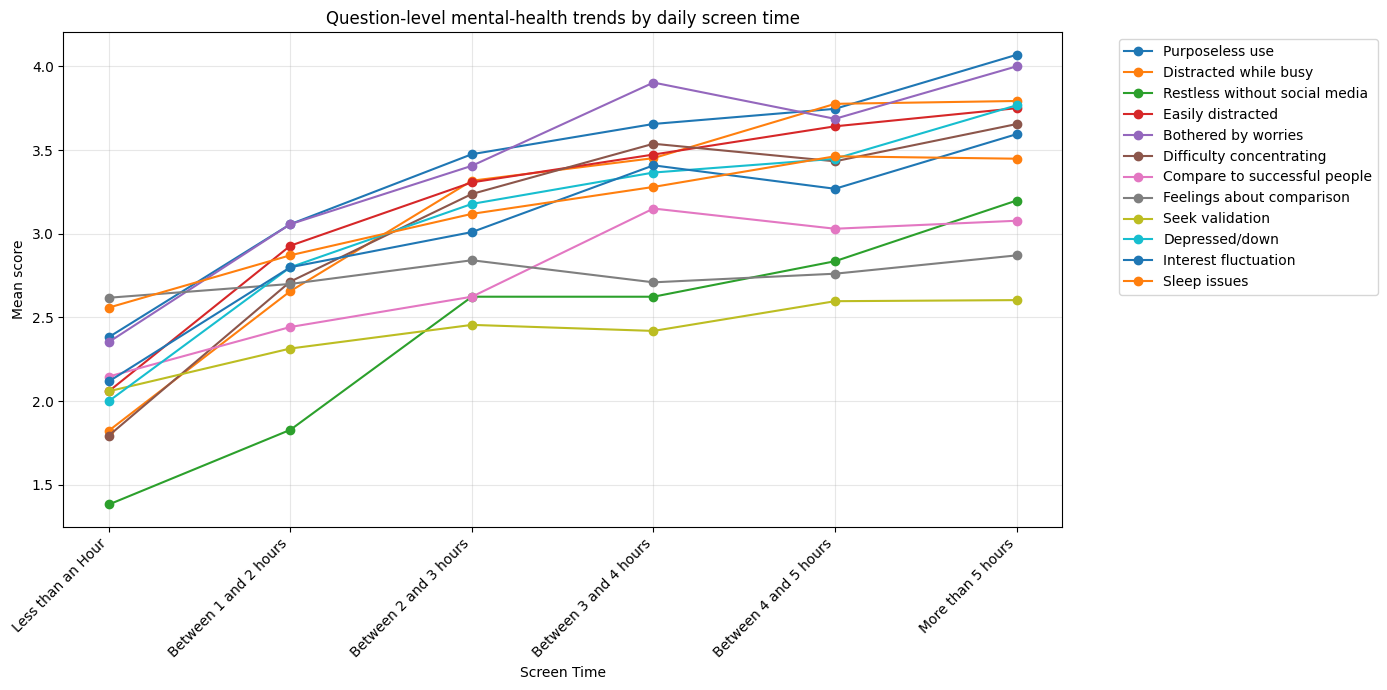

In [16]:
# ── Individual question trends by daily screen time ───────────────────────────
question_columns = list(questions_map.keys())
question_labels = {
    'q9':  'Purposeless use',
    'q10': 'Distracted while busy',
    'q11': 'Restless without social media',
    'q12': 'Easily distracted',
    'q13': 'Bothered by worries',
    'q14': 'Difficulty concentrating',
    'q15': 'Compare to successful people',
    'q16': 'Feelings about comparison',
    'q17': 'Seek validation',
    'q18': 'Depressed/down',
    'q19': 'Interest fluctuation',
    'q20': 'Sleep issues',
}

plt.figure(figsize=(14, 7))
for col in question_columns:
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-', label=question_labels.get(col, col))

plt.title('Question-level mental-health trends by daily screen time')
plt.xlabel('Screen Time')
plt.ylabel('Mean score')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


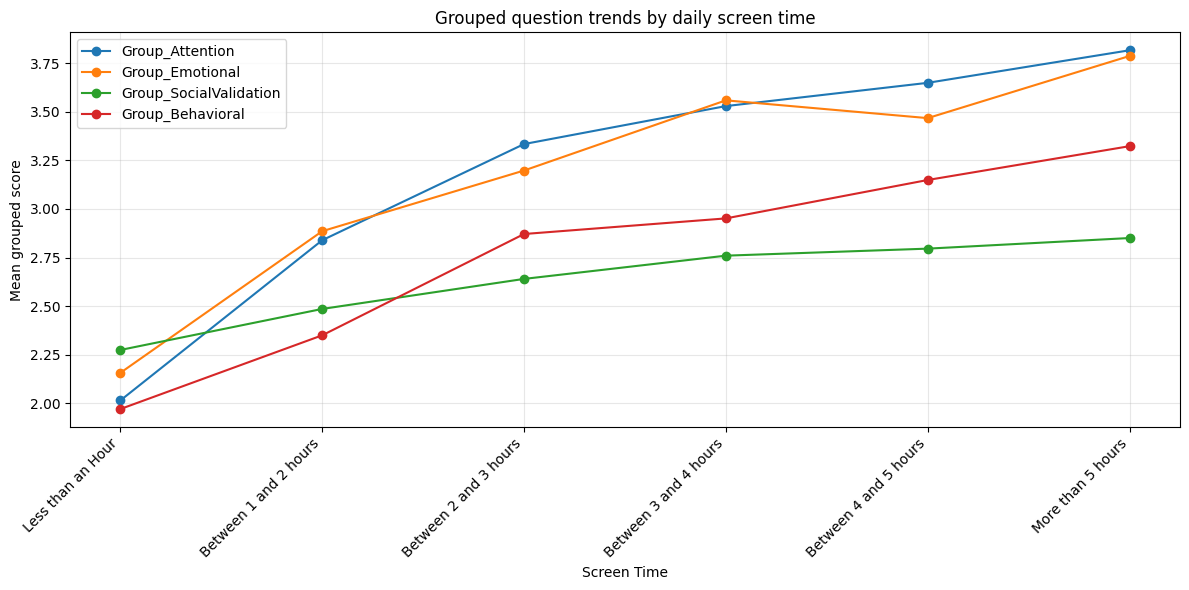

In [17]:
# ── Combined grouped overview plot ───────────────────────────────────────────
grouped_columns = ['Group_Attention', 'Group_Emotional', 'Group_SocialValidation', 'Group_Behavioral']

plt.figure(figsize=(12, 6))
for col in grouped_columns:
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-', label=col)

plt.title('Grouped question trends by daily screen time')
plt.xlabel('Screen Time')
plt.ylabel('Mean grouped score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
# ── Export aggregated data for the HTML timeline ─────────────────────────────
grouped.to_csv('../data/aggregated_screentime_trends_volume_2.csv', index=False)
print(f"✓ Exported aggregated_screentime_trends_volume_2.csv  |  Shape: {grouped.shape}")


✓ Exported aggregated_screentime_trends_volume_2.csv  |  Shape: (6, 17)


## Digital Personas (clustering)

Building on the thematic groupings from the timeline, we assign each respondent a **Digital Persona**:

| Persona | Criteria |
|---|---|
| **The Doomscroller** | Score ≥ 4 on purposeless use *and* restlessness; ≥ 4 h/day |
| **The Anxious** | Score ≥ 4 on worries *and* feeling down |
| **The Distracted** | Score ≥ 4 on distractability *and* concentration difficulty |
| **The Insecure** | Score ≥ 4 on validation-seeking *or* social comparison |
| **Professional** | Score ≤ 2 on distraction while busy *and* restlessness |
| **Regular User** | Score ≤ 3 on worries; ≤ 2 h/day |
| **Casual Surfer** | 2–4 h/day; moderate scores — catch-all middle group |
| **Off-grid** | Reports not using social media |
| **Uncategorized** | Does not match any cluster |

This tab drives a fully reader-driven story: users can filter by age group, marital status, and occupation, and click on individual dots to read each respondent's profile.


In [19]:
# ── Categorisation function ───────────────────────────────────────────────────
def categorize_user(row):
    if row['6. Do you use social media?'] == 'No':
        return 'Off-grid'

    avg_time = row['8. What is the average time you spend on social media every day?']
    high_use = avg_time in ['More than 5 hours', 'Between 4 and 5 hours']
    mid_use  = avg_time in ['Between 2 and 3 hours', 'Between 3 and 4 hours']

    if high_use and row['9. How often do you find yourself using Social media without a specific purpose?'] >= 4:
        if row["11. Do you feel restless if you haven't used Social media in a while?"] >= 4:
            return 'The Doomscroller'

    if (row['13. On a scale of 1 to 5, how much are you bothered by worries?'] >= 4 and
            row['18. How often do you feel depressed or down?'] >= 4):
        return 'The Anxious'

    if (row['12. On a scale of 1 to 5, how easily distracted are you?'] >= 4 and
            row['14. Do you find it difficult to concentrate on things?'] >= 4):
        return 'The Distracted'

    if (row['17. How often do you look to seek validation from features of social media?'] >= 4 or
            row['15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?'] >= 4):
        return 'The Insecure'

    if (row['10. How often do you get distracted by Social media when you are busy doing something?'] <= 2 and
            row["11. Do you feel restless if you haven't used Social media in a while?"] <= 2):
        return 'Professional'

    if avg_time in ['Less than an Hour', 'Between 1 and 2 hours']:
        if row['13. On a scale of 1 to 5, how much are you bothered by worries?'] <= 3:
            return 'Regular User'

    if mid_use or row['9. How often do you find yourself using Social media without a specific purpose?'] >= 3:
        return 'Casual Surfer'

    return 'Uncategorized'

data['Digital Persona'] = data.apply(categorize_user, axis=1)

print("\n--- Digital Persona counts ---")
print(data['Digital Persona'].value_counts())



--- Digital Persona counts ---
Digital Persona
The Anxious         151
Casual Surfer        70
Professional         68
The Distracted       62
The Insecure         60
The Doomscroller     47
Regular User         16
Uncategorized         4
Off-grid              3
Name: count, dtype: int64


In [20]:
# ── Export enriched dataset ───────────────────────────────────────────────────
out_file = '../data/smmh_with_personas.csv'
data.to_csv(out_file, index=False)
print(f"✓ Dataset exported → {out_file}")
data.head()


✓ Dataset exported → ../data/smmh_with_personas.csv


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?",Gender_Grouped,mean_mh_score,n_5_scores,Digital Persona
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord, Reddit",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5,Male,3.583333,5,The Distracted
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord, Reddit",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5,Female,3.583333,4,The Anxious
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5,Female,2.916667,2,The Anxious
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2,Female,2.916667,2,The Anxious
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1,Female,3.666667,3,The Anxious


In [21]:
# ── Optional diagnostics: raw category values used by the persona rules ───────
print("\n--- Unique Relationship Statuses ---")
print(data['3. Relationship Status'].unique())

print("\n--- Unique Occupation Statuses ---")
print(data['4. Occupation Status'].unique())

print("\n--- Unique Responses for Social-Media-Related Organisations ---")
print(data['5. What type of organizations are you affiliated with?'].unique())



--- Unique Relationship Statuses ---
<StringArray>
['In a relationship', 'Single', 'Married', 'Divorced']
Length: 4, dtype: str

--- Unique Occupation Statuses ---
<StringArray>
['University Student', 'School Student', 'Salaried Worker', 'Retired']
Length: 4, dtype: str

--- Unique Responses for Social-Media-Related Organisations ---
<StringArray>
[                    'University',                        'Private',
                              nan,             'School, University',
                        'Company',                'School, Private',
            'University, Company',                      'Goverment',
               'Company, Private',                         'School',
 'University, Goverment, Private',   'University, Company, Private',
            'University, Private',                'University, N/A',
    'School, University, Private',          'University, Goverment',
 'University, Company, Goverment',                'School, Company',
                    'School,